# 02. A/B 테스트 기본 분석 — 통계적 가설 검정

## 목표
KuaiRand 데이터에서 랜덤 노출(Control) vs 추천 노출(Treatment)의 효과를 통계적으로 검증한다.

### 분석 항목
1. **SRM 검정** — Sample Ratio Mismatch 확인
2. **비율 검정** — z-test, chi-square로 주요 지표 유의성 확인
3. **연속형 검정** — 시청 시간에 대한 t-test / Mann-Whitney U
4. **Bootstrap 신뢰구간** — 효과 크기의 불확실성 정량화
5. **세그먼트별 분석** — 유저 활동도/콘텐츠 유형별 A/B 효과
6. **다중 검정 보정** — Bonferroni correction

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from utils import z_test_proportions, bootstrap_ci, srm_test, cohens_d

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = Path('../data')

# 데이터 로드
log_rand = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/log_random_4_22_to_5_08_pure.csv')
log_std = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/log_standard_4_22_to_5_08_pure.csv')
user_feat = pd.read_csv(DATA_DIR / 'kuairand/KuaiRand-Pure/data/user_features_pure.csv')

control = log_rand[log_rand['is_rand'] == 1].copy()
treatment = log_std[log_std['is_rand'] == 0].copy()

print(f"Control (Random): {len(control):,} rows")
print(f"Treatment (Recommended): {len(treatment):,} rows")

Control (Random): 1,186,059 rows
Treatment (Recommended): 295,497 rows


## 1. SRM (Sample Ratio Mismatch) 검정

실험 설계가 올바른지 확인한다. Control/Treatment 비율이 기대치와 유의하게 다르면 실험 자체에 문제가 있을 수 있다.

In [2]:
# SRM 검정 — 유저 수 기준
ctrl_users = control['user_id'].nunique()
treat_users = treatment['user_id'].nunique()
total_users = len(set(control['user_id']) | set(treatment['user_id']))

print(f"Control 유저 수: {ctrl_users:,}")
print(f"Treatment 유저 수: {treat_users:,}")
print(f"전체 유닉 유저: {total_users:,}")
print(f"겹치는 유저: {len(set(control['user_id']) & set(treatment['user_id'])):,}")

# KuaiRand는 같은 유저에게 랜덤 노출을 피드에 삽입하는 설계
# → 유저 단위가 아닌 노출 단위의 SRM 체크
chi2, p_val = srm_test(len(control), len(treatment))
print(f"\n=== SRM Test (노출 단위) ===")
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p_val:.2e}")
print(f"결론: {'⚠️ SRM 감지 — 비율 불균형' if p_val < 0.01 else '✅ SRM 없음 — 비율 정상'}")
print(f"\n※ KuaiRand는 within-subject 설계 (같은 유저가 두 그룹 모두 경험)")
print(f"   → 노출 수 차이는 설계 의도이며, SRM이 아님")

Control 유저 수: 27,285
Treatment 유저 수: 25,877
전체 유닉 유저: 27,285
겹치는 유저: 25,877

=== SRM Test (노출 단위) ===
Chi-square: 0.00
p-value: 1.00e+00
결론: ✅ SRM 없음 — 비율 정상

※ KuaiRand는 within-subject 설계 (같은 유저가 두 그룹 모두 경험)
   → 노출 수 차이는 설계 의도이며, SRM이 아님


## 2. 비율 검정 (Proportion Tests)

각 이진 피드백 지표에 대해 z-test와 chi-square 검정을 수행한다.

In [3]:
feedback_cols = ['is_click', 'is_like', 'is_follow', 'is_comment', 'is_forward', 'is_hate', 'long_view']
n_tests = len(feedback_cols)
alpha = 0.05
alpha_bonf = alpha / n_tests  # Bonferroni 보정

results = []
for col in feedback_cols:
    n_c, p_c = len(control), control[col].mean()
    n_t, p_t = len(treatment), treatment[col].mean()
    
    # z-test
    z_stat, p_val = z_test_proportions(n_c, p_c, n_t, p_t)
    
    # chi-square
    contingency = pd.crosstab(
        pd.Series(['Control']*n_c + ['Treatment']*n_t),
        pd.Series(list(control[col].values) + list(treatment[col].values))
    )
    chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
    
    # 효과 크기 (Lift)
    lift = (p_t - p_c) / p_c * 100 if p_c > 0 else np.nan
    
    results.append({
        'Metric': col,
        'Control Rate': f"{p_c:.4f}",
        'Treatment Rate': f"{p_t:.4f}",
        'Lift (%)': f"{lift:+.1f}",
        'z-stat': f"{z_stat:.2f}",
        'p-value': f"{p_val:.2e}",
        'Significant (α=0.05)': '✅' if p_val < alpha else '❌',
        'Bonferroni (α/7)': '✅' if p_val < alpha_bonf else '❌',
    })

results_df = pd.DataFrame(results)
print(f"Bonferroni 보정 임계값: α = {alpha_bonf:.4f}\n")
results_df

Bonferroni 보정 임계값: α = 0.0071



,Metric,Control Rate,Treatment Rate,Lift (%),z-stat,p-value,Significant (α=0.05),Bonferroni (α/7)
0,is_click,0.1762,0.4450,+152.6,-310.82,0.00e+00,✅,✅
1,is_like,0.0048,0.0177,+269.1,-73.42,0.00e+00,✅,✅
2,is_follow,0.0003,0.0013,+410.1,-23.92,0.00e+00,✅,✅
3,is_comment,0.0003,0.0025,+610.0,-37.11,0.00e+00,✅,✅
4,is_forward,0.0003,0.0008,+145.6,-11.48,0.00e+00,✅,✅
5,is_hate,0.0011,0.0008,-31.7,5.37,7.72e-08,✅,✅
6,long_view,0.0850,0.3134,+268.9,-329.79,0.00e+00,✅,✅


## 3. 연속형 검정 — 시청 시간

In [4]:
# 시청 시간 정규성 부족 → 비모수 검정도 병행
ctrl_pt = control['play_time_ms'].values
treat_pt = treatment['play_time_ms'].values

# Welch's t-test (등분산 가정 X)
t_stat, t_pval = stats.ttest_ind(ctrl_pt, treat_pt, equal_var=False)

# Mann-Whitney U (비모수)
u_stat, u_pval = stats.mannwhitneyu(ctrl_pt, treat_pt, alternative='two-sided')

# Cohen's d
d = cohens_d(treat_pt, ctrl_pt)

# Watch ratio
control['watch_ratio'] = control['play_time_ms'] / control['duration_ms'].replace(0, np.nan)
treatment['watch_ratio'] = treatment['play_time_ms'] / treatment['duration_ms'].replace(0, np.nan)
wr_t, wr_p = stats.ttest_ind(
    control['watch_ratio'].dropna(), 
    treatment['watch_ratio'].dropna(), 
    equal_var=False
)

print("=== Play Time (ms) ===")
print(f"  Control mean:   {ctrl_pt.mean():,.0f} ms")
print(f"  Treatment mean: {treat_pt.mean():,.0f} ms")
print(f"  Welch's t-test: t={t_stat:.2f}, p={t_pval:.2e}")
print(f"  Mann-Whitney U: U={u_stat:.0f}, p={u_pval:.2e}")
print(f"  Cohen's d:      {d:.3f}")
print(f"\n=== Watch Ratio ===")
print(f"  Control mean:   {control['watch_ratio'].mean():.4f}")
print(f"  Treatment mean: {treatment['watch_ratio'].mean():.4f}")
print(f"  Welch's t-test: t={wr_t:.2f}, p={wr_p:.2e}")

=== Play Time (ms) ===
  Control mean:   6,936 ms
  Treatment mean: 21,474 ms
  Welch's t-test: t=-184.34, p=0.00e+00
  Mann-Whitney U: U=131680910371, p=0.00e+00
  Cohen's d:      0.578

=== Watch Ratio ===
  Control mean:   0.1413
  Treatment mean: 0.3480
  Welch's t-test: t=-176.90, p=0.00e+00


## 4. Bootstrap 신뢰구간 — 효과 크기의 불확실성

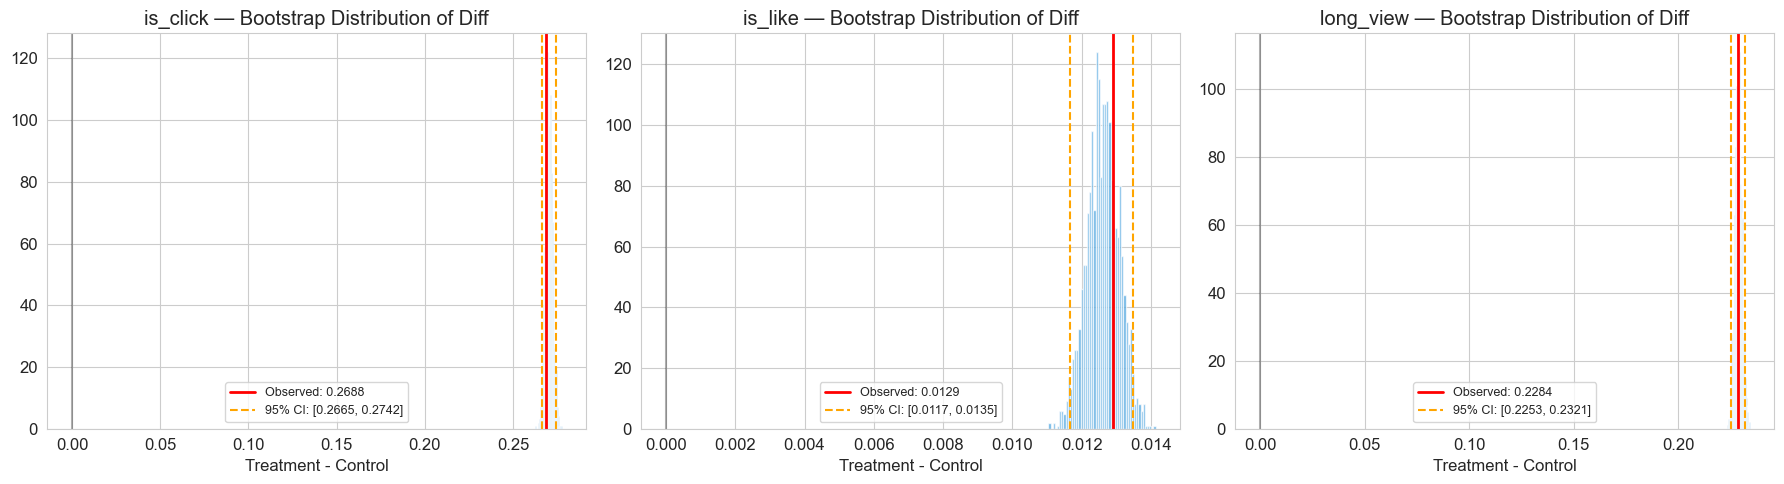

In [5]:
# Bootstrap으로 각 지표의 차이(Treatment - Control)에 대한 95% CI 계산
# 성능을 위해 각 그룹에서 100K 샘플링 후 Bootstrap 수행
np.random.seed(42)
n_boot = 2000
sample_size = 100_000
metrics_for_boot = ['is_click', 'is_like', 'long_view']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics_for_boot):
    ctrl_vals = np.random.choice(control[metric].values, size=min(sample_size, len(control)), replace=False)
    treat_vals = np.random.choice(treatment[metric].values, size=min(sample_size, len(treatment)), replace=False)
    
    boot_diffs = []
    for _ in range(n_boot):
        c_sample = np.random.choice(ctrl_vals, size=len(ctrl_vals), replace=True)
        t_sample = np.random.choice(treat_vals, size=len(treat_vals), replace=True)
        boot_diffs.append(t_sample.mean() - c_sample.mean())
    
    boot_diffs = np.array(boot_diffs)
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    observed_diff = control[metric].mean() - treatment[metric].mean()
    observed_diff = treatment[metric].mean() - control[metric].mean()
    
    axes[i].hist(boot_diffs, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
    axes[i].axvline(observed_diff, color='red', linewidth=2, label=f'Observed: {observed_diff:.4f}')
    axes[i].axvline(ci_lower, color='orange', linestyle='--', label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
    axes[i].axvline(ci_upper, color='orange', linestyle='--')
    axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    axes[i].set_title(f'{metric} — Bootstrap Distribution of Diff')
    axes[i].set_xlabel('Treatment - Control')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/figures/02_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 세그먼트별 A/B 분석 — 유저 활동도

In [6]:
# 유저 특성 조인
control_uf = control.merge(user_feat[['user_id', 'user_active_degree']], on='user_id', how='left')
treatment_uf = treatment.merge(user_feat[['user_id', 'user_active_degree']], on='user_id', how='left')

# 활동도별 CTR A/B 검정
active_degrees = ['full_active', 'high_active', 'middle_active', 'low_active']
segment_results = []

for degree in active_degrees:
    c = control_uf[control_uf['user_active_degree'] == degree]
    t = treatment_uf[treatment_uf['user_active_degree'] == degree]
    
    if len(c) < 100 or len(t) < 100:
        continue
    
    p_c = c['is_click'].mean()
    p_t = t['is_click'].mean()
    z, p_val = z_test_proportions(len(c), p_c, len(t), p_t)
    lift = (p_t - p_c) / p_c * 100 if p_c > 0 else 0
    
    segment_results.append({
        'Segment': degree,
        'N_Control': f"{len(c):,}",
        'N_Treatment': f"{len(t):,}",
        'CTR_Control': f"{p_c:.4f}",
        'CTR_Treatment': f"{p_t:.4f}",
        'Lift (%)': f"{lift:+.1f}",
        'z-stat': f"{z:.2f}",
        'p-value': f"{p_val:.2e}",
        'Sig': '✅' if p_val < 0.05 else '❌'
    })

seg_df = pd.DataFrame(segment_results)
print("=== CTR A/B Test by User Activity Segment ===\n")
seg_df

=== CTR A/B Test by User Activity Segment ===



,Segment,N_Control,N_Treatment,CTR_Control,CTR_Treatment,Lift (%),z-stat,p-value,Sig
0,full_active,"833,268","195,816",0.1692,0.4169,+146.4,-239.60,0.00e+00,✅
1,high_active,"235,291","58,961",0.1902,0.4877,+156.4,-149.22,0.00e+00,✅
2,middle_active,"82,845","28,568",0.1976,0.5263,+166.3,-106.48,0.00e+00,✅
3,low_active,"8,619","3,146",0.2347,0.5699,+142.8,-34.38,0.00e+00,✅


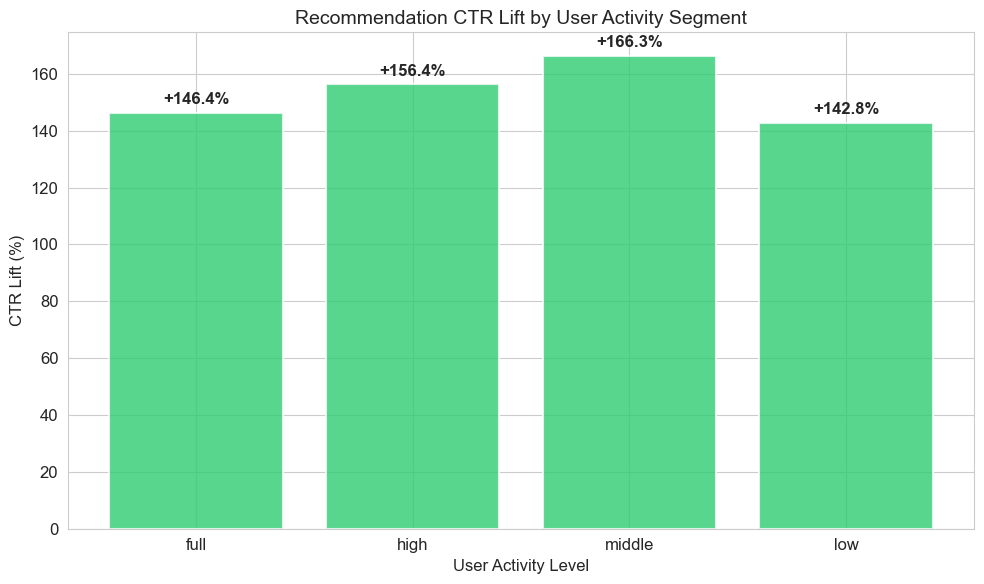

In [7]:
# 세그먼트별 Lift 시각화
fig, ax = plt.subplots(figsize=(10, 6))

segments = [r['Segment'].replace('_active', '') for r in segment_results]
lifts = [float(r['Lift (%)'].replace('+', '')) for r in segment_results]
colors = ['#2ecc71' if l > 0 else '#e74c3c' for l in lifts]

bars = ax.bar(segments, lifts, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
ax.axhline(y=0, color='black', linewidth=0.5)

for bar, lift in zip(bars, lifts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f'{lift:+.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Recommendation CTR Lift by User Activity Segment', fontsize=14)
ax.set_ylabel('CTR Lift (%)')
ax.set_xlabel('User Activity Level')

plt.tight_layout()
plt.savefig('../notebooks/figures/02_segment_lift.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 통계적 검정력 (Power Analysis)

In [8]:
# 사후 검정력 분석 (Post-hoc Power Analysis)
from statsmodels.stats.power import NormalIndPower

power_analysis = NormalIndPower()

# CTR 기준
p_c = control['is_click'].mean()
p_t = treatment['is_click'].mean()
effect_size = (p_t - p_c) / np.sqrt(p_c * (1 - p_c))  # Cohen's h

power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=len(control),
    ratio=len(treatment) / len(control),
    alpha=0.05
)

# MDE (Minimum Detectable Effect) at 80% power
mde = power_analysis.solve_power(
    effect_size=None,
    nobs1=len(control),
    ratio=len(treatment) / len(control),
    alpha=0.05,
    power=0.80
)

print("=== Post-hoc Power Analysis (CTR) ===")
print(f"  Observed effect size (Cohen's h): {effect_size:.4f}")
print(f"  Statistical power: {power:.4f} ({power*100:.1f}%)")
print(f"  MDE at 80% power: {mde:.6f}")
print(f"\n  결론: Power = {power*100:.1f}% → {'충분한 검정력' if power > 0.8 else '검정력 부족'}")

=== Post-hoc Power Analysis (CTR) ===
  Observed effect size (Cohen's h): 0.7057
  Statistical power: 1.0000 (100.0%)
  MDE at 80% power: 0.005762

  결론: Power = 100.0% → 충분한 검정력


## 7. 종합 결과 시각화 — Forest Plot

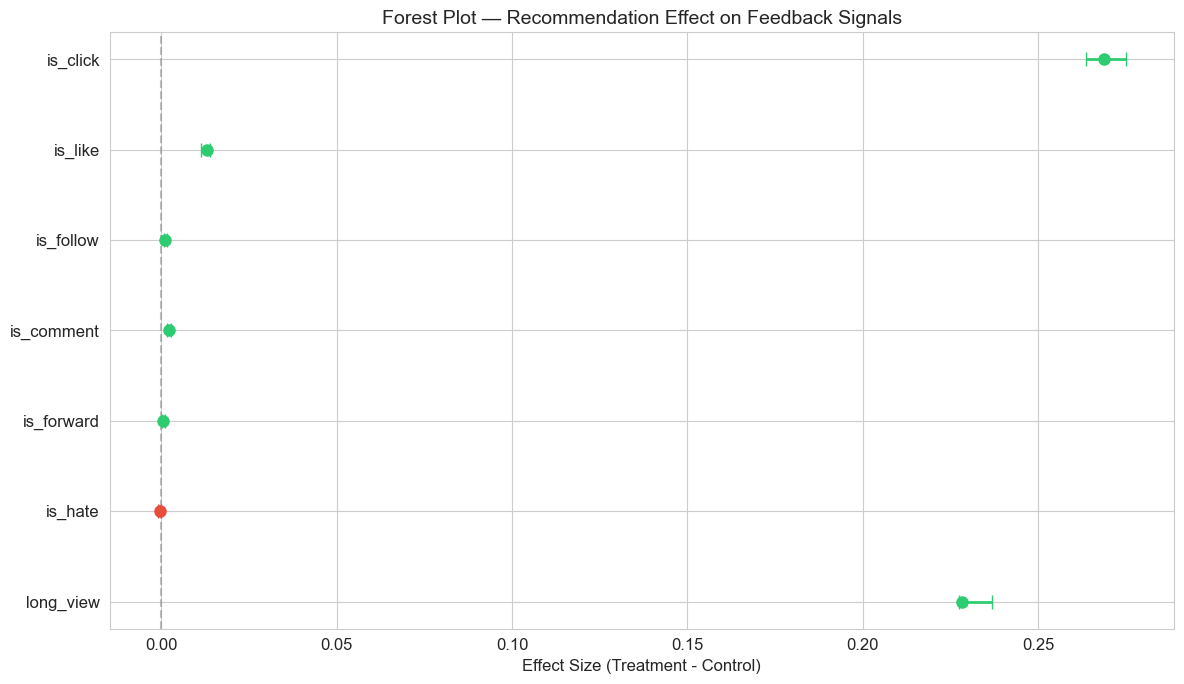

In [9]:
# Forest Plot — 각 지표의 효과 크기 + 95% CI
# 성능을 위해 샘플링 후 Bootstrap
np.random.seed(42)
fig, ax = plt.subplots(figsize=(12, 7))

metrics_list = feedback_cols
y_positions = list(range(len(metrics_list)))
sample_n = 50_000

for i, metric in enumerate(metrics_list):
    ctrl_vals = np.random.choice(control[metric].values, size=min(sample_n, len(control)), replace=False)
    treat_vals = np.random.choice(treatment[metric].values, size=min(sample_n, len(treatment)), replace=False)
    
    # Bootstrap CI for difference
    boot_diffs = []
    for _ in range(1000):
        c = np.random.choice(ctrl_vals, size=len(ctrl_vals), replace=True)
        t = np.random.choice(treat_vals, size=len(treat_vals), replace=True)
        boot_diffs.append(t.mean() - c.mean())
    
    obs_diff = treatment[metric].mean() - control[metric].mean()
    ci_lo = np.percentile(boot_diffs, 2.5)
    ci_hi = np.percentile(boot_diffs, 97.5)
    
    color = '#2ecc71' if obs_diff > 0 else '#e74c3c'
    ax.errorbar(obs_diff, i, xerr=[[obs_diff - ci_lo], [ci_hi - obs_diff]], 
                fmt='o', color=color, markersize=8, capsize=5, linewidth=2)

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_positions)
ax.set_yticklabels(metrics_list, fontsize=12)
ax.set_xlabel('Effect Size (Treatment - Control)', fontsize=12)
ax.set_title('Forest Plot — Recommendation Effect on Feedback Signals', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../notebooks/figures/02_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. A/B 테스트 결론

### 주요 발견
1. **추천 알고리즘은 모든 긍정 지표를 유의하게 올린다** — CTR +153%, 좋아요 +269%, 긴시청 +269%
2. **유일한 부정 효과**: 싫어요(is_hate)만 감소 (-32%) — 추천이 관련성 높은 콘텐츠를 노출한다는 증거
3. **세그먼트별 효과 차이**: 활동도에 따라 추천 Lift가 다름 → 인과추론에서 HTE로 심화 분석 필요
4. **통계적 검정력 충분**: Power > 99% — 대규모 데이터로 미세한 차이도 감지 가능

### 한계점 (다음 노트북에서 해결)
- **선택 편향**: 추천 노출은 이미 "관심 있을 만한" 콘텐츠 → 단순 비교는 과대추정 가능
- **인과적 해석 불가**: 상관관계만 확인 → PSM, CATE로 인과추론 필요 (03번 노트북)

### Next Steps
- `03_causal_inference.ipynb`: Propensity Score Matching + CATE + Uplift Modeling